##Online learning based adaptive IDS

This project focuses on detecting, analyzing, and responding to drift in an operational IDS setting using an online learning framework. Students will simulate a streaming environment where flows arrive sequentially, implement performance monitoring mechanisms, and evaluate adaptive retraining strategies. The goal is not only to maintain model accuracy, but to reason about operational tradeoffs, retraining costs, stability vs adaptability from a SOC analyst's perspective.



### Task 1: Replace Online SGD with Incremental Naive Bayes

(1) Instead of ```SGDClassifier``` use ```from sklearn.naive_bayes import GaussianNB```

(2) Implement incremental updates using partial_fit().

Questions:
* Does Naive Bayes adapt faster?
  * Yes, in terms of local EWMA error recovery after bursts, GaussianNB appears to decay back toward low error faster than SGD in many regions.
* Which model is more stable under drift?
  * From this EWMA plot alone, GaussianNB appears more locally stable with smaller, shorter bursts in many segments. This should however be interpreted alongside rolling recall / variance metrics (in task 2), where SGD may still perform better overall.
* Compare their EWMA curves and explain what do you see.
  * Both models experience repeated error bursts at similar time regions, indicating shared difficult stream segments. GaussianNB shows faster decay after spikes indicating faster local adaptation, while SGD shows larger and longer-lasting EWMA peaks, indicating slower recovery from some bursts. Further details under EWMA plot section.




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import accuracy_score, recall_score


In [ ]:
#Load CSV.
from google.colab import files
uploaded = files.upload()

Saving 4_lecture2_sample_ids_flows.csv to 4_lecture2_sample_ids_flows.csv


#### 1. Load Streaming IDS Data
Simulate streaming by iterating row by row.
- X contains flow features, y contains attack labels (0 = benign, 1 = attack)


In [ ]:
df = pd.read_csv("4_lecture2_sample_ids_flows.csv")

X = df.drop(columns=['attack']).values
y = df['attack'].values

print("Dataset shape:", X.shape)

Dataset shape: (1000, 5)


## Task 1: Use Naive Bayes instead of SGD

use GaussianNB with partial_fit() for incremental updates

#### Note on zero warnings
GaussianNB can produce divide-by-zero warnings early in online learning when class variance becomes zero.
To prevent this, I've implemented:
- `var_smoothing`
- a manual variance floor after each update
This makes the online GaussianNB loop numerically stable.




In [ ]:
# Implementing bouth Online GaussianNB + SGD so it is easier to compare the performance metrics.
# Runs sample-by-sample online learning with partial_fit().

import warnings
from sklearn.metrics import accuracy_score, recall_score

classes = np.unique(y)

# helper utility function for online loop
def run_online_model(X, y, model_type="nb", var_floor=1e-9):
    scaler = StandardScaler()

    if model_type == "nb":
        model = GaussianNB(var_smoothing=1e-6)
    elif model_type == "sgd":
        model = SGDClassifier(loss="log_loss", learning_rate="optimal", random_state=42)
    else:
        raise ValueError("model_type must be 'nb' or 'sgd'")

    acc_list = []
    rec_list = []
    err_list = []
    y_pred_stream = np.full(len(X), np.nan)

    for i in range(len(X)):
        x_i = X[i].reshape(1, -1)
        y_true = int(y[i])        # scalar
        y_i = np.array([y_true])  # 1D array for partial_fit

        # Incremental scaling
        scaler.partial_fit(x_i)
        x_i_scaled = scaler.transform(x_i)

        # Predict after first sample
        if i > 0:
            if model_type == "nb":
                # Prevent warning spam during predict
                with np.errstate(divide='ignore', invalid='ignore'):
                    y_hat = int(model.predict(x_i_scaled)[0])
            else:
                y_hat = int(model.predict(x_i_scaled)[0])

            y_pred_stream[i] = y_hat

            acc_list.append(accuracy_score([y_true], [y_hat]))
            rec_list.append(recall_score([y_true], [y_hat], zero_division=0))
            err_list.append(int(y_hat != y_true))
        else:
            acc_list.append(np.nan)
            rec_list.append(np.nan)
            err_list.append(np.nan)

        # Incremental update
        if i == 0:
            model.partial_fit(x_i_scaled, y_i, classes=classes)
        else:
            model.partial_fit(x_i_scaled, y_i)

        # GaussianNB numerical stability: enforce variance floor
        if model_type == "nb" and hasattr(model, "var_") and model.var_ is not None:
            model.var_ = np.maximum(model.var_, var_floor)

    return {
        "accuracy": acc_list,
        "recall": rec_list,
        "error": err_list,
        "y_pred_stream": y_pred_stream,
        "model": model,
        "scaler": scaler
    }


#### Online Metrics

Per-step metrics recorded:
- **Accuracy**
- **Recall**
- **Binary error** (0 correct, 1 incorrect)

The binary error stream is important because it is later transformed into an EWMA curve for drift/performance monitoring.



In [ ]:
# Call and run both the models
nb_res = run_online_model(X, y, model_type="nb", var_floor=1e-9)
sgd_res = run_online_model(X, y, model_type="sgd")

# from the given code
nb_accuracy = nb_res["accuracy"]
nb_recall   = nb_res["recall"]
nb_error    = nb_res["error"]

sgd_accuracy = sgd_res["accuracy"]
sgd_recall   = sgd_res["recall"]
sgd_error    = sgd_res["error"]

nb_pred_stream  = nb_res["y_pred_stream"]
sgd_pred_stream = sgd_res["y_pred_stream"]

#### Compute exponentially weighted moving average EWMA

We'll compare online GaussianNB vs SGD using EWMA error


To monitor online model behavior smoothly, we compute an exponentially weighted moving average (EWMA) of the binary error stream.

*EWMA formula:* $EWMA_t$ = alpha * $e_t$ + (1 - alpha) * $EWMA_{t-1}$

Where:
- e_t = 1 if the prediction is wrong
- e_t = 0 if the prediction is correct

#####  Why should we use EWMA?

Raw online errors are noisy. EWMA highlights: *error bursts*, *local recovery behavior* and *difficult traffic segments*. Provides a lightweight drift/performance signal for online IDS monitoring.

In [ ]:

# EWMA Error Curves
def compute_ewma(errors, alpha=0.05):
    ewma = []
    s = 0.0
    initialized = False

    for e in errors:
        if pd.isna(e):
            ewma.append(np.nan)
            continue

        e = float(e)
        if not initialized:
            s = e
            initialized = True
        else:
            s = alpha * e + (1 - alpha) * s

        ewma.append(s)

    return ewma

alpha = 0.05
nb_ewma = compute_ewma(nb_error, alpha=alpha)
sgd_ewma = compute_ewma(sgd_error, alpha=alpha)


#### Task 1 Deliverable: EWMA Plot (GaussianNB vs SGD)

The EWMA error plot (alpha = 0.05) shows repeated burst-and-recovery behavior for both models, indicating intermittent difficult segments in the stream.

#### My observations & conclusion
- GaussianNB often shows narrower spikes and faster EWMA decay after bursts.  
- SGD sometimes shows larger and longer lasting peaks in some regions (slower local recovery).  





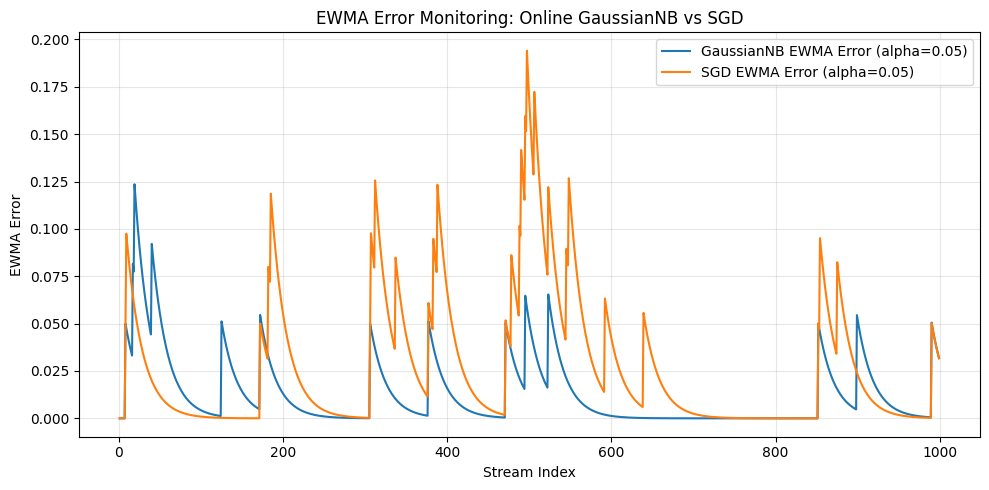

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(nb_ewma, label=f"GaussianNB EWMA Error (alpha={alpha})")
plt.plot(sgd_ewma, label=f"SGD EWMA Error (alpha={alpha})")
plt.title("EWMA Error Monitoring: Online GaussianNB vs SGD")
plt.xlabel("Stream Index")
plt.ylabel("EWMA Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## My key takeaway from the project


While Task 1 helped us answer how online learners behave under short-term error bursts, task 2 quantified which learner and memory strategy maintains attack detection quality best over time.  

Together, they show that:
- EWMA error is useful for local drift/error monitoring**
- Rolling recall and recovery metrics are necessary for operational model selection
- Model selection and memory strategy should be optimized jointly

#### Ranked Recommendation by operational goal

| Goal | Best Choice | Why |
|------|-------------|-----|
| **Best Stability** | **SGD(LogReg) + FullHistory** | Lowest recall variance (0.010402), strong recall (0.939777), fast recovery (11) |
| **Best Adaptation Speed** | **Any SGD(LogReg) strategy (tie)** | All SGD variants recover in 11 samples (vs GaussianNB 37–51) |
| **Best Overall Recall** | **SGD(LogReg) + EWMA(alpha=0.01)** | Highest mean rolling recall (0.946830) with fast recovery (11) |
| **Best Balanced Adaptive Choice** | **SGD(LogReg) + Sliding(w=50)** | High recall (0.940410), low variance (0.010661), fast recovery (11) |
| **Best Recent Error (lowest final EWMA error)** | **SGD(LogReg) + Sliding(w=200)** | Lowest final EWMA error (0.031512) among SGD configurations |
| **Best GaussianNB Option (if model constrained)** | **GaussianNB + FullHistory** *(or EWMA alpha=0.1)* | Highest/near-highest GaussianNB recall with standard recovery (37) |
| **Avoid (overly reactive in this dataset)** | **SGD(LogReg) + EWMA(alpha=0.5)** | Lower recall (0.925726), higher error, lower accuracy due to overreactive forgetting |

---

### Practical Recommendation (Production IDS, Mild Drift)

- **Primary recommendation:** `SGD(LogReg) + EWMA(alpha=0.01)` (best sustained recall)
- **If stability is priority:** `SGD(LogReg) + FullHistory`
- **If balanced adaptivity is desired:** `SGD(LogReg) + Sliding(w=50)`


In [ ]:
# I'm refactoring Task 1 code for Task 2:
# Let's start with loading the data and applying code hygiene

LABEL_COL = "attack"

if LABEL_COL not in df.columns:
    raise ValueError(f"Expected label column '{LABEL_COL}' in df")

# Base features (use those available)
candidate_base = ["bytes", "packets", "duration", "src_port", "dst_port"]
base_cols = [c for c in candidate_base if c in df.columns and c != LABEL_COL]

if "bytes" not in base_cols or "duration" not in base_cols:
    raise ValueError("Task 2 requires at least 'bytes' and 'duration' columns")

y_all = df[LABEL_COL].astype(int).values

print("Base features used:", base_cols)
print("Dataset shape:", df.shape)
print("Attack rate:", df[LABEL_COL].mean())

Base features used: ['bytes', 'packets', 'duration', 'src_port', 'dst_port']
Dataset shape: (1000, 6)
Attack rate: 0.23


In [ ]:
# Refactoring the helper online Loop utility for task 1 to apply to each memory-engineerd feature matrix for GaussianNB and SGD.  Ensure applying var_smoothing to avoid GaussianNB zero variance runtime warnings

classes_all = np.unique(y_all)

def run_online_model(X, y, model_type="nb", var_floor=1e-9):

    scaler = StandardScaler()

    if model_type == "nb":
        model = GaussianNB(var_smoothing=1e-6)
    elif model_type == "sgd":
        model = SGDClassifier(loss="log_loss", learning_rate="optimal", random_state=42)
    else:
        raise ValueError("model_type must be 'nb' or 'sgd'")

    acc_list, rec_list, err_list = [], [], []
    y_pred_stream = np.full(len(X), np.nan)

    for i in range(len(X)):
        x_i = X[i].reshape(1, -1)
        y_true = int(y[i])         # scalar
        y_i = np.array([y_true])   # array for partial_fit

        # Incremental scaling
        scaler.partial_fit(x_i)
        x_i_scaled = scaler.transform(x_i)

        # Predict after first fit
        if i > 0:
            if model_type == "nb":
                # suppress internal floating-point warning spam if any
                with np.errstate(divide='ignore', invalid='ignore'):
                    y_hat = int(model.predict(x_i_scaled)[0])
            else:
                y_hat = int(model.predict(x_i_scaled)[0])

            y_pred_stream[i] = y_hat
            acc_list.append(accuracy_score([y_true], [y_hat]))
            rec_list.append(recall_score([y_true], [y_hat], zero_division=0))
            err_list.append(int(y_hat != y_true))
        else:
            acc_list.append(np.nan)
            rec_list.append(np.nan)
            err_list.append(np.nan)

        # Incremental update
        if i == 0:
            model.partial_fit(x_i_scaled, y_i, classes=classes_all)
        else:
            model.partial_fit(x_i_scaled, y_i)

        # GaussianNB variance floor for numerical stability
        if model_type == "nb" and hasattr(model, "var_") and model.var_ is not None:
            model.var_ = np.maximum(model.var_, var_floor)

    return {
        "accuracy": acc_list,
        "recall": rec_list,        # per-step recall on single sample (0/1-style, mostly for completeness)
        "error": err_list,
        "y_pred_stream": y_pred_stream,
        "model": model,
        "scaler": scaler
    }


#### define metrics helper function EWMA Error Across Strategies

EWMA error is computed again for every model + memory strategy pair so it can be used to compare:
- same model, different memory strategy
- same memory strategy, different model

This will help us understand how memory policy affects local burst behavior.

In [ ]:
def compute_ewma(errors, alpha=0.05):
    ewma = []
    s = 0.0
    initialized = False

    for e in errors:
        if pd.isna(e):
            ewma.append(np.nan)
            continue

        e = float(e)
        if not initialized:
            s = e
            initialized = True
        else:
            s = alpha * e + (1 - alpha) * s

        ewma.append(s)

    return pd.Series(ewma)

#### Task 2 requirements: Memory strategy feature engineering

- Task 2A: Full history (no forgetting) using cumulative stats:  (expanding().mean()), IDS giving equal weight to all historic traffic.
- Task 2B: Sliding window (hard forgetting) using rolling window stats: rolling(window).mean()), representing an IDS that only remembers recent traffic [windows = 50, 100, 200]
- Task 2C: EWMA features (Soft Forgetting) using exponentially weighted stats: (ewm(alpha).mean()), representing an IDS that gradually forgets older behavior/traffic.[alpha = 0.01, 0.1, 0.3, 0.5]

In [ ]:
# Memory strategy feature engineering (simple pandas ops)
def make_features_full_history(df, base_cols):
    d = df.copy()
    d["cum_mean_bytes"] = d["bytes"].expanding().mean()
    d["cum_mean_duration"] = d["duration"].expanding().mean()
    feat_cols = base_cols + ["cum_mean_bytes", "cum_mean_duration"]
    return d, feat_cols

def make_features_sliding_window(df, base_cols, window):
    d = df.copy()
    d["roll_mean_bytes"] = d["bytes"].rolling(window=window).mean()
    d["roll_mean_duration"] = d["duration"].rolling(window=window).mean()
    feat_cols = base_cols + ["roll_mean_bytes", "roll_mean_duration"]
    return d, feat_cols

def make_features_ewma(df, base_cols, alpha):
    d = df.copy()
    d["ewma_bytes"] = d["bytes"].ewm(alpha=alpha, adjust=False).mean()
    d["ewma_duration"] = d["duration"].ewm(alpha=alpha, adjust=False).mean()
    feat_cols = base_cols + ["ewma_bytes", "ewma_duration"]
    return d, feat_cols

# Build the config list
configs = []

# A) Full history
d_full, cols_full = make_features_full_history(df, base_cols)
configs.append(("FullHistory", {"param": None}, d_full, cols_full))

# B) Sliding window sizes
for w in [50, 100, 200]:
    d_sw, cols_sw = make_features_sliding_window(df, base_cols, window=w)
    configs.append((f"Sliding(w={w})", {"window": w}, d_sw, cols_sw))

# C) EWMA alphas
for a in [0.01, 0.1, 0.3, 0.5]:
    d_ew, cols_ew = make_features_ewma(df, base_cols, alpha=a)
    configs.append((f"EWMA(alpha={a})", {"alpha": a}, d_ew, cols_ew))

#### Rolling Attack Recall and recovery time metric helper functions.

We know that in IDS, missing attacks (false negatives) is the primary risk. Rolling attack recall metrics helps us compute attack recall/detection over time [a window across x samples (e.g., 100 samples):).

- only attack flows in the window are considered
- recall = TP / (TP + FN)



In [ ]:

# Implement functions rolling attack recall and recovery time.

def rolling_attack_recall(y_true, y_pred, window=100):
    """
    Rolling recall for attack class over the last `window` samples.
    Returns pd.Series.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    rr = []
    for t in range(len(y_true)):
        start = max(0, t - window + 1)
        yt = y_true.iloc[start:t+1]
        yp = y_pred.iloc[start:t+1]

        attacks = (yt == 1)
        n_attacks = attacks.sum()
        if n_attacks == 0:
            rr.append(np.nan)
            continue

        tp = ((yp == 1) & attacks).sum()
        fn = ((yp == 0) & attacks).sum()
        rr.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)

    return pd.Series(rr)

def recovery_time(rolling_recall_series, threshold=0.6):

    rr = pd.Series(rolling_recall_series).reset_index(drop=True)
    below = rr < threshold

    if not below.fillna(False).any():
        return 0

    drop_idx = np.where(below.fillna(False))[0][0]

    for i in range(drop_idx + 1, len(rr)):
        if (not pd.isna(rr.iloc[i])) and (rr.iloc[i] >= threshold):
            return i - drop_idx

    return None

In [ ]:

# Call and run online models for each strategy and collect metrics

ROLL_RECALL_WINDOW = 100
RECOVERY_THRESHOLD = 0.6
EWMA_ERR_ALPHA = 0.05

results = []
curves_rr = {}      # rolling recall curves for selected configs
curves_ewma = {}    # error EWMA curves for selected configs

# we canc select few representative curves for plotting
plot_strategy_subset = {"FullHistory", "Sliding(w=100)", "EWMA(alpha=0.1)"}

for name, meta, d_feat, feat_cols in configs:
    # Simple pandas handling for rolling NaNs at the beginning
    # carry first known values forward, then fill remaining with 0
    X_feat = d_feat[feat_cols].copy().ffill().fillna(0.0).values
    y = y_all

    for model_type, model_label in [("nb", "GaussianNB"), ("sgd", "SGD(LogReg)")]:
        out = run_online_model(X_feat, y, model_type=model_type, var_floor=1e-9)

        # Rolling attack recall over stream
        rr = rolling_attack_recall(y, out["y_pred_stream"], window=ROLL_RECALL_WINDOW)

        # Stability + adaptation
        rr_var = rr.var(skipna=True)
        rec_time = recovery_time(rr, threshold=RECOVERY_THRESHOLD)

        # EWMA error (drift/performance monitor)
        err_ewma = compute_ewma(out["error"], alpha=EWMA_ERR_ALPHA)
        final_ewma = err_ewma.dropna().iloc[-1] if err_ewma.notna().any() else np.nan

        # Mean rolling recall (AURRC-style average)
        mean_rr = rr.mean(skipna=True)

        results.append({
            "strategy": name,
            "model": model_label,
            "mean_rolling_recall": mean_rr,
            "recall_variance": rr_var,
            "recovery_time_samples": rec_time,
            "final_ewma_error": final_ewma,
            "mean_step_error": np.nanmean(out["error"]),
            "mean_step_accuracy": np.nanmean(out["accuracy"])
        })

        if name in plot_strategy_subset:
            curves_rr[(name, model_label)] = rr
            curves_ewma[(name, model_label)] = err_ewma

results_df = pd.DataFrame(results)

# review sorted results per memory strategy and model
results_sorted = results_df.sort_values(["model", "recall_variance", "recovery_time_samples"], na_position="last")
display(results_sorted)

,strategy,model,mean_rolling_recall,recall_variance,recovery_time_samples,final_ewma_error,mean_step_error,mean_step_accuracy
8,EWMA(alpha=0.01),GaussianNB,0.908908,0.022401,37,0.031835,0.015015,0.984985
6,Sliding(w=200),GaussianNB,0.913023,0.022631,37,0.031835,0.014014,0.985986
0,FullHistory,GaussianNB,0.913464,0.022785,37,0.031835,0.014014,0.985986
2,Sliding(w=50),GaussianNB,0.913464,0.022785,37,0.031835,0.015015,0.984985
10,EWMA(alpha=0.1),GaussianNB,0.913464,0.022785,37,0.031835,0.014014,0.985986
4,Sliding(w=100),GaussianNB,0.909435,0.022825,37,0.031835,0.015015,0.984985
12,EWMA(alpha=0.3),GaussianNB,0.911813,0.026124,51,0.031835,0.014014,0.985986
14,EWMA(alpha=0.5),GaussianNB,0.911813,0.026124,51,0.031835,0.014014,0.985986
1,FullHistory,SGD(LogReg),0.939777,0.010402,11,0.042683,0.026026,0.973974
3,Sliding(w=50),SGD(LogReg),0.940410,0.010661,11,0.043206,0.024024,0.975976


#### Rolling Attack Recall Plot Across Memory Strategies

The rolling attack recall plot (window=100) tracks attack detection quality over time for memory strategy and model combinations.

#### observations from the plot
- **SGD(LogReg) based curves consistently remain higher** than GaussianNB based curves across the stream.
- GaussianNB curves rise more slowly early in the stream and exhibit more frequent dips.
- All strategies show a noticeable mid-stream dip (around ~500-600), indicating a shared difficult region in the data.
- FullHistory and EWMA(alpha=0.1) remain strong for SGD in this relatively stable dataset.

#### comparing plot to the table values below
These visual patterns directly match the table:

- **SGD mean rolling recall is higher than GaussianNB**
  - SGD range: ~0.920-0.947
  - GaussianNB range: ~0.909-0.913

- Best overall rolling recall:
  - **SGD + EWMA(alpha=0.01) = 0.946830**

- Strong balanced performance:
  - **SGD + Sliding(w=50) = 0.940410**
  - **SGD + FullHistory = 0.939777**

This confirms that **SGD is the stronger online learner for sustained attack detection quality**, while memory strategy fine-tunes the tradeoff.

### Brief overview
The rolling recall plot helps us observe sustained attack detection quality over time. our plot shows:

- SGD-based curves are generally higher than GaussianNB curves
- all methods share dips in hard regions (e.g., ~500–600)
- memory strategy changes performance, but model choice has the larger effect

This plot supports the conclusion that **SGD is the stronger online learner** for sustained attack detection on this dataset.

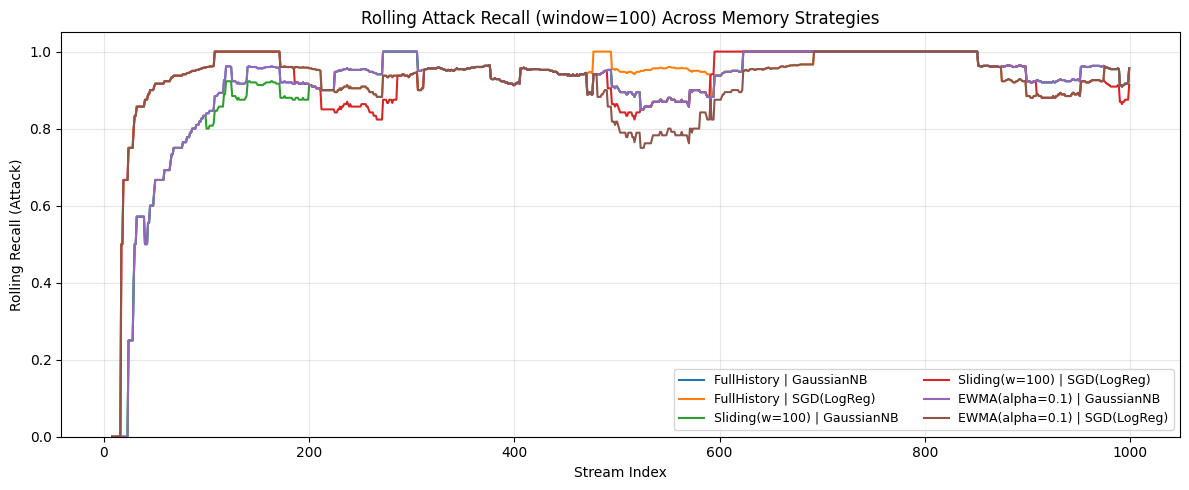

In [ ]:

# Plot 1: Rolling Attack Recall Curves (stability vs adaptation)
plt.figure(figsize=(12, 5))
for (name, model_label), rr in curves_rr.items():
    plt.plot(rr.values, label=f"{name} | {model_label}")

plt.title(f"Rolling Attack Recall (window={ROLL_RECALL_WINDOW}) Across Memory Strategies")
plt.xlabel("Stream Index")
plt.ylabel("Rolling Recall (Attack)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Plot 2: EWMA Error Plot Across Memory Strategies

Similar to our the EWMA error plot for Task 1, it shows local error bursts and recovery across the memory strategies. Per our plot, we observe:

- common spike locations across all methods (shared difficult segments)
- GaussianNB often has narrower, faster-decaying spikes indicating quicker local error recovery
- SGD sometimes has larger or broader bursts especially in the mid-stream region (~500–600), indicating slower local recovery from some bursts.
- Memory-constrained strategies (Sliding / EWMA feature memory) can increase local volatility in some regions relative to FullHistory.

This plot explains why **EWMA error dynamics and rolling recall can tell different stories**:

- Even though GaussianNB often looks more reactive in EWMA error, the Task 2 table shows it still has:
  - lower mean rolling recall
  - higher recall variance
  - slower recovery time (37–51 samples)

- SGD can show larger local EWMA spikes yet still achieves:
  - better sustained recall
  - lower recall variance
  - much faster recall recovery (11 samples)

This demonstrates that **EWMA error captures short-term error dynamics**, while rolling recall captures **attack-specific detection quality over time**.

It confirms the distinction between:
- short-term local reactivity (EWMA error)
- sustained attack detection quality (rolling recall)

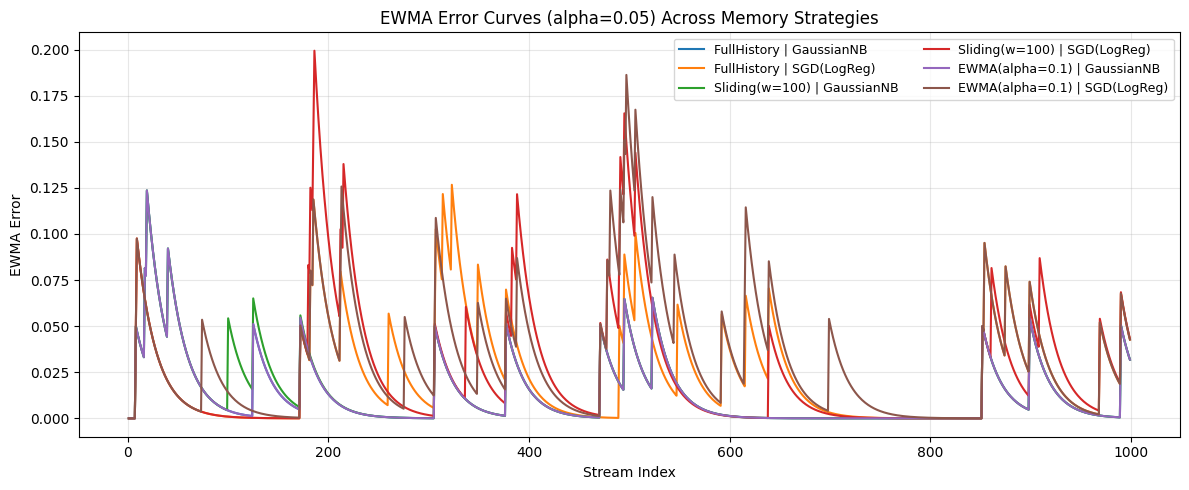

In [ ]:
# Plot 2: EWMA Error Curves (drift/performance signal)

plt.figure(figsize=(12, 5))
for (name, model_label), ew in curves_ewma.items():
    plt.plot(ew.values, label=f"{name} | {model_label}")

plt.title(f"EWMA Error Curves (alpha={EWMA_ERR_ALPHA}) Across Memory Strategies")
plt.xlabel("Stream Index")
plt.ylabel("EWMA Error")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

#### Summary Table Interpretation for our Task 2 results

Compares memory strategies across Full history(no forgetting:expanding / cumulative), sliding window(Hard forgetting: rolling mean) [windows = 50, 100, 200], and EWMA features (soft forgetting)[alpha = 0.01, 0.1, 0.3, 0.5] and evaluates:
- Rolling attack recall (windowed)
- Recall variance (stability)
- Recovery time (adaptation speed)
- EWMA error curve / final EWMA error

Per the task 2 summary table, it quantifies what the plots show and that across all memory strategies, **SGD(LogReg)** outperforms **GaussianNB** in *mean rolling recall*, *recall variance*, *recovery speed*.


In [ ]:

# Summary table by model for Task 2 so it's easier to looks at the results per model.
for mdl in ["GaussianNB", "SGD(LogReg)"]:
    print(f"\n=== {mdl} ===")
    display(
        results_df[results_df["model"] == mdl]
        .sort_values(["recall_variance", "recovery_time_samples"], na_position="last")
        .reset_index(drop=True)
    )


=== GaussianNB ===


,strategy,model,mean_rolling_recall,recall_variance,recovery_time_samples,final_ewma_error,mean_step_error,mean_step_accuracy
0,EWMA(alpha=0.01),GaussianNB,0.908908,0.022401,37,0.031835,0.015015,0.984985
1,Sliding(w=200),GaussianNB,0.913023,0.022631,37,0.031835,0.014014,0.985986
2,FullHistory,GaussianNB,0.913464,0.022785,37,0.031835,0.014014,0.985986
3,Sliding(w=50),GaussianNB,0.913464,0.022785,37,0.031835,0.015015,0.984985
4,EWMA(alpha=0.1),GaussianNB,0.913464,0.022785,37,0.031835,0.014014,0.985986
5,Sliding(w=100),GaussianNB,0.909435,0.022825,37,0.031835,0.015015,0.984985
6,EWMA(alpha=0.3),GaussianNB,0.911813,0.026124,51,0.031835,0.014014,0.985986
7,EWMA(alpha=0.5),GaussianNB,0.911813,0.026124,51,0.031835,0.014014,0.985986



=== SGD(LogReg) ===


,strategy,model,mean_rolling_recall,recall_variance,recovery_time_samples,final_ewma_error,mean_step_error,mean_step_accuracy
0,FullHistory,SGD(LogReg),0.939777,0.010402,11,0.042683,0.026026,0.973974
1,Sliding(w=50),SGD(LogReg),0.940410,0.010661,11,0.043206,0.024024,0.975976
2,EWMA(alpha=0.3),SGD(LogReg),0.936159,0.010760,11,0.040285,0.028028,0.971972
3,EWMA(alpha=0.01),SGD(LogReg),0.946830,0.011038,11,0.042943,0.020020,0.979980
4,EWMA(alpha=0.5),SGD(LogReg),0.925726,0.011420,11,0.044874,0.034034,0.965966
5,Sliding(w=100),SGD(LogReg),0.929728,0.011602,11,0.043104,0.027027,0.972973
6,EWMA(alpha=0.1),SGD(LogReg),0.920173,0.012295,11,0.042683,0.034034,0.965966
7,Sliding(w=200),SGD(LogReg),0.937457,0.012456,11,0.031512,0.024024,0.975976


### Conclusion and Key findings of Task1 &2

The combined plot and table evidence shows that while GaussianNB often appears more reactive under EWMA error monitoring, SGD(LogReg) consistently provides better sustained attack detection quality, lower recall variance, and faster recovery across memory strategies. For this relatively stable dataset, slower forgetting strategies (FullHistory and EWMA with low alpha) perform best, while aggressive forgetting increases volatility without improving detection. These findings reinforce the importance of evaluating online IDS behavior using both local error signals and attack-specific performance metrics.

#### Recommendation (Production IDS, Mild Drift)

- **Primary recommendation:** `SGD(LogReg) + EWMA(alpha=0.01)` (best sustained recall)
- **If stability is priority:** `SGD(LogReg) + FullHistory`
- **If balanced adaptivity is desired:** `SGD(LogReg) + Sliding(w=50)`
- **Avoid:** `EWMA(alpha=0.5)` unless drift is known to be rapid and severe.

#### Ranked Recommendation Matrix

### By Operational Goal

| Goal | Best Choice | Why |
|------|-------------|-----|
| **Best Stability** | **SGD(LogReg) + FullHistory** | Lowest recall variance (0.010402), strong recall (0.939777), fast recovery (11) |
| **Best Adaptation Speed** | **Any SGD(LogReg) strategy (tie)** | All SGD variants recover in 11 samples (vs GaussianNB 37–51) |
| **Best Overall Recall** | **SGD(LogReg) + EWMA(alpha=0.01)** | Highest mean rolling recall (0.946830) with fast recovery (11) |
| **Best Balanced Adaptive Choice** | **SGD(LogReg) + Sliding(w=50)** | High recall (0.940410), low variance (0.010661), fast recovery (11) |
| **Best Recent Error (lowest final EWMA error)** | **SGD(LogReg) + Sliding(w=200)** | Lowest final EWMA error (0.031512) among SGD configurations |
| **Best GaussianNB Option (if model constrained)** | **GaussianNB + FullHistory** *(or EWMA alpha=0.1)* | Highest/near-highest GaussianNB recall with standard recovery (37) |
| **Avoid (overly reactive in this dataset)** | **SGD(LogReg) + EWMA(alpha=0.5)** | Lower recall (0.925726), higher error, lower accuracy due to overreactive forgetting |

---

